## Encoding
### Opdracht

Zoals aan het begin van de cursus besproken gaat het project over handgeschreven nummers herekennen op een MysteryDevice met de volgende eigenschappen:

- Input scherm waarmee een nieuwe plaatje als ndarray aangemaakt kan worden door de gebruiker.
- Zeer beperkt RAM (256 KB)
- Beperkte opslag (1 MB voor 
programma + model)
- Geen GPU
- Embedded python


MysteryDevice opslaglimiet: 1 MB
Volledige MNIST dataset: 52 MB

Dus het opslaan van MNST voor training doeleinden zou niet werken. Maar in ons geval maakt het ook niet uit, want we kunnen onze AI methode op een PC trainen.

Echter, hebben we nog steeds een encoding van afbeeldingen nodig omdat de gebruiker wel een afbeelding invoert.

#### Hoe ziet de input eruit tijdens inference?

De gebruiker tekent op het touchscreen → dat moet naar 28×28 of een andere encoding worden gebracht.

#### Hoeveel RAM gebruikt die inputrepresentatie?

784 bytes (1 byte per pixel) -> heel laag
maar 32‑bits floats → 784 × 4 = 3 KB -> al een stuk hoger

Ontwerp een encoding van een MNIST plaatje die zo min mogelijk geheugen nodig heeft op het MysteryDevice om je Decision Tree uit de vorige opdracht te draaien op 1 sample. 

Mogelijk heb je al wat gedaan in de vorige stap, maar kijk of je het nog meer kan verbeteren.
Het moet:

- minder geheugen gebruiken
- minder rekenkracht nodig hebben
- toch informatie bewaren om cijfers te herkennen

Maak eventueel gebruik aan de volgende onderweren, maar ga vooral zelf experimenteren:
- binning
(“donker / medium / licht” → 3 waarden)

- binary thresholding
(zwart/wit → 1 bit per pixel)

- downscaling
(28×28 → 14×14 → 196 features)

- flattening
(784 → 784 vector)

- quantization
(8-bit → 4-bit → 2-bit per pixel)

- feature extraction
(bijv. “hoeveel inkt zit links/rechts/boven/onder?”)
- sparse encoding
(alleen niet‑nul pixels bewaren)

- Ga je normaliseren? Hoe?
- Ga je flattenen of 2D laten staan?
- Ga je binning toepassen op pixelwaarden?
- Ga je ordinale encoding toepassen op pixelintensiteiten?
- Ga je pixelwaarden reduceren (bijv. “donker, medium, licht”)?
- Ga je één pixel gebruiken, of alle 784?

**Ga ook een eigen “encoding” bedenken!**

In [1]:
from tensorflow.keras.datasets import mnist
import numpy as np

(X_train, y_train), _ = mnist.load_data()
sample = X_train[0]  # 28x28, uint8, waarden 0-255

print(f"Originele afbeelding: {sample.shape}, dtype={sample.dtype}, {sample.nbytes} bytes")
print(f"Label: {y_train[0]}")

Originele afbeelding: (28, 28), dtype=uint8, 784 bytes
Label: 5


In [2]:
# je kunt de volgende template gebruiken hier

def encode(img):
    # Stap 1: Downscale 28×28 → 14×14 door het maximum van elk 2×2 blok te nemen
    klein = img.reshape(14, 2, 14, 2).max(axis=(1, 3))
    # Stap 2: Binary thresholding — pixel boven 128 wordt 1 (inkt), de rest 0 (leeg)
    encoded = (klein > 128).astype(np.uint8)
    return encoded

encoded_sample = encode(sample)
encoded_sample

# bepaal hoeveel het gebruikt
encoded_sample.nbytes

196

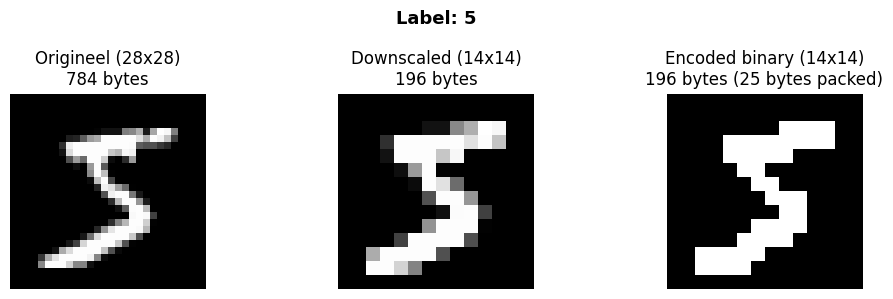

In [3]:
import matplotlib.pyplot as plt

# Tussenresultaat: alleen downscaled, nog niet binary
klein = sample.reshape(14, 2, 14, 2).max(axis=(1, 3))

fig, axes = plt.subplots(1, 3, figsize=(10, 3))

axes[0].imshow(sample, cmap='gray')
axes[0].set_title('Origineel (28x28)\n784 bytes')
axes[0].axis('off')

axes[1].imshow(klein, cmap='gray')
axes[1].set_title('Downscaled (14x14)\n196 bytes')
axes[1].axis('off')

axes[2].imshow(encoded_sample, cmap='gray')
axes[2].set_title('Encoded binary (14x14)\n196 bytes (25 bytes packed)')
axes[2].axis('off')

plt.suptitle(f'Label: {y_train[0]}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


Beantwoord ook de volgende vragen:

- Hoeveel RAM kost één afbeelding?
- Hoeveel RAM kost 100 afbeeldingen?
- Hoe groot zou het model maximaal mogen zijn?
- Kun je de encoding verder comprimeren?
- Is er informatie verloren gegaan?
- Kun je nog steeds het cijfer herkennen?

**Antwoorden op de ontwerpvragen:**

- **Normaliseren?** Nee — we gebruiken binary thresholding, geen normalisatie naar 0–1.
- **Flattenen of 2D?** We laten het 2D (14×14) — dat past bij de structuur van een afbeelding.
- **Binning?** Nee — we gebruiken binary thresholding (eenvoudiger dan binning).
- **Ordinale encoding?** Nee — we reduceren naar slechts 2 waarden: 0 (leeg) en 1 (inkt).
- **Pixelwaarden reduceren?** Ja — van 256 mogelijke waarden (uint8) naar 2 waarden (0 of 1).
- **Hoeveel pixels?** Alle 196 pixels (na downscaling van 784 naar 196).

**Eigen encoding:** Downscaling (28×28 → 14×14) gecombineerd met Binary Thresholding.
We pakken het maximale pixel in elk 2×2 blok (zodat dunne lijnen niet verdwijnen) en zetten daarna alles naar 0 of 1.

In [4]:
een_afbeelding     = encoded_sample.nbytes
honderd            = een_afbeelding * 100
ram_budget         = 256 * 1024
model_budget       = ram_budget - een_afbeelding

print(f"RAM voor één afbeelding:   {een_afbeelding} bytes")
print(f"RAM voor 100 afbeeldingen: {honderd} bytes ({honderd / 1024:.1f} KB)")
print(f"RAM-budget (256 KB):       {ram_budget} bytes")
print(f"Ruimte over voor model:    {model_budget} bytes ({model_budget / 1024:.1f} KB)")
print()

# Verder comprimeren met packbits (1 bit per pixel in plaats van 1 byte)
packed = np.packbits(encoded_sample)
print(f"Verder comprimeren? Ja — met numpy packbits: {packed.nbytes} bytes (was {een_afbeelding} bytes)")
print()
print("Informatie verloren? Ja — grijstinten zijn weg, alleen zwart/wit.")
print("Nog herkenbaar?     Ja — de vorm van het cijfer blijft zichtbaar.")

RAM voor één afbeelding:   196 bytes
RAM voor 100 afbeeldingen: 19600 bytes (19.1 KB)
RAM-budget (256 KB):       262144 bytes
Ruimte over voor model:    261948 bytes (255.8 KB)

Verder comprimeren? Ja — met numpy packbits: 25 bytes (was 196 bytes)

Informatie verloren? Ja — grijstinten zijn weg, alleen zwart/wit.
Nog herkenbaar?     Ja — de vorm van het cijfer blijft zichtbaar.


### Meerdere encodings vergelijken

We testen vier manieren om een MNIST-afbeelding te encoderen en vergelijken geheugengebruik en nauwkeurigheid.

| # | Methode | Grootte | Bits/pixel |
|---|---------|---------|-----------|
| 1 | Downscale + Binary threshold | 25 bytes (packed) | 1 |
| 2 | Downscale + Binning (3 niveaus) | ~49 bytes | 2 |
| 3 | Downscale + Quantization 4-bit | 98 bytes | 4 |
| 4 | Zone-features (eigen) | 64 bytes (16 × float32) | – |


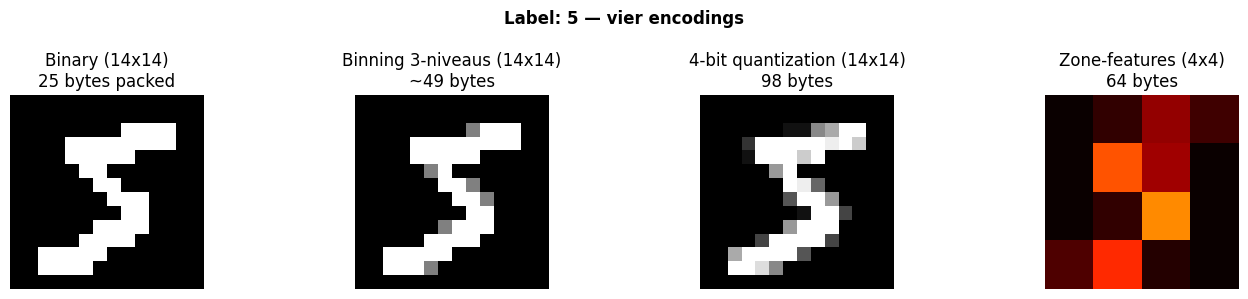

Origineel (uint8 flat):           784 bytes
Encoding 1 — binary packed:        25 bytes
Encoding 2 — binning (~2 bits):    49 bytes (geschat)
Encoding 3 — 4-bit quantized:      98 bytes
Encoding 4 — zone-features:        64 bytes


In [5]:
# Encoding 2: Binning (3 niveaus: donker / medium / licht)
def encode_binning(img):
    klein = img.reshape(14, 2, 14, 2).max(axis=(1, 3))
    return np.digitize(klein, bins=[85, 171]).astype(np.uint8)

# Encoding 3: Quantization 4-bit (16 niveaus i.p.v. 256)
def encode_4bit(img):
    klein = img.reshape(14, 2, 14, 2).max(axis=(1, 3))
    return (klein // 16).astype(np.uint8)

# Encoding 4 (eigen): Zone-features
# Verdeel 28x28 in 4x4 = 16 zones; sla per zone het percentage inkt op.
# Behoud ruimtelijke informatie (waar zit de inkt?) met slechts 16 getallen.
def encode_zones(img, n=4):
    h, w = img.shape
    zh, zw = h // n, w // n
    return np.array([
        np.mean(img[r*zh:(r+1)*zh, c*zw:(c+1)*zw] > 128)
        for r in range(n) for c in range(n)
    ], dtype=np.float32)

# Toon alle vier encodings naast elkaar
fig, axes = plt.subplots(1, 4, figsize=(14, 3))

axes[0].imshow(encode(sample), cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Binary (14x14)\n25 bytes packed')
axes[0].axis('off')

axes[1].imshow(encode_binning(sample), cmap='gray', vmin=0, vmax=2)
axes[1].set_title('Binning 3-niveaus (14x14)\n~49 bytes')
axes[1].axis('off')

axes[2].imshow(encode_4bit(sample), cmap='gray', vmin=0, vmax=15)
axes[2].set_title('4-bit quantization (14x14)\n98 bytes')
axes[2].axis('off')

axes[3].imshow(encode_zones(sample).reshape(4, 4), cmap='hot', vmin=0, vmax=1)
axes[3].set_title('Zone-features (4x4)\n64 bytes')
axes[3].axis('off')

plt.suptitle(f'Label: {y_train[0]} — vier encodings', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Geheugen per sample op een rijtje
print(f"Origineel (uint8 flat):         {sample.nbytes:>5} bytes")
print(f"Encoding 1 — binary packed:     {np.packbits(encode(sample)).nbytes:>5} bytes")
print(f"Encoding 2 — binning (~2 bits): {encode_binning(sample).nbytes // 4:>5} bytes (geschat)")
print(f"Encoding 3 — 4-bit quantized:   {encode_4bit(sample).nbytes // 2:>5} bytes")
print(f"Encoding 4 — zone-features:     {encode_zones(sample).nbytes:>5} bytes")


In [ ]:
# Accuracy meten: train een Decision Tree per encoding en vergelijk op de testset
from tensorflow.keras.datasets import mnist
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

(Xtr_raw, ytr), (Xte_raw, yte) = mnist.load_data()

def _ds(X):  # downscale batch 28x28 -> 14x14 via max-pool 2x2
    return X.reshape(-1, 14, 2, 14, 2).max(axis=(2, 4))

batch_encoders = {
    "Binary (14x14)":        lambda X: (_ds(X) > 128).astype(np.uint8).reshape(len(X), -1),
    "Binning 3-niveaus":     lambda X: np.digitize(_ds(X), bins=[85, 171]).astype(np.uint8).reshape(len(X), -1),
    "4-bit quantization":    lambda X: (_ds(X) // 16).astype(np.uint8).reshape(len(X), -1),
    "Zone-features (4x4)":   lambda X: np.stack([encode_zones(img) for img in X]),
    "Volledig 784 (baseline)": lambda X: X.reshape(len(X), -1),
}

print(f"{'Encoding':24s} {'features':>9} {'accuracy':>9}")
print("-" * 44)
for naam, fn in batch_encoders.items():
    Xtr, Xte = fn(Xtr_raw), fn(Xte_raw)
    clf = DecisionTreeClassifier(max_depth=12, random_state=0).fit(Xtr, ytr)
    acc = accuracy_score(yte, clf.predict(Xte))
    print(f"{naam:24s} {Xtr.shape[1]:>9} {acc:>9.3f}")


### Conclusie

We vergelijken de encodings op **geheugen** én op **accuracy** (Decision Tree, max_depth=12, gemeten op de MNIST-testset in de cel hierboven):

| Methode | Geheugen | Features | Accuracy |
|---|---|---|---|
| **Binary threshold (packed)** | **25 bytes** | 196 | **0.88** |
| Binning (3 niveaus) | ~49 bytes | 196 | 0.87 |
| 4-bit quantization | 98 bytes | 196 | 0.88 |
| Zone-features (eigen) | 64 bytes | 16 | 0.75 |
| Volledig 784 (baseline) | 784 bytes | 784 | 0.88 |

**Beste keuze voor het MysteryDevice: Downscale + Binary thresholding (packed).**

- **Kleinste geheugen:** 25 bytes per afbeelding → 100 afbeeldingen = 2,5 KB, ruim binnen het RAM-budget van 256 KB.
- **Beste accuracy:** 0.88 — gelijk aan de volledige 784-pixel baseline, terwijl het 30× minder geheugen gebruikt.
- Eenvoudig te berekenen: 1 bit per pixel, geen GPU, geen zware libraries.

**De eigen zone-encoding was een leerzame mislukking.** Met 16 features is hij verreweg het compactst in featurecount (goedkoopste boom om te evalueren), maar de accuracy zakt naar 0.75. Door per zone alleen het inktpercentage te bewaren gaat te veel vormdetail verloren om cijfers betrouwbaar te onderscheiden. Geheugen wint hij óók niet van binary (64 vs 25 bytes). Conclusie: voor deze taak is agressief downscalen tot zones een stap te ver.

**Informatie verloren?** Ja — grijstinten en exacte pixelwaarden zijn weg. Maar bij de binary encoding blijft genoeg *vorm* over: de accuracy blijft op het niveau van de volledige afbeelding.

**Verder comprimeren?** De binary encoding zit al op het minimum van 1 bit/pixel (25 bytes). Verder comprimeren zou pixels moeten weggooien, en dat kost — zoals de zone-features laten zien — accuracy.
